# Team 1 — Human-in-the-Loop: Auditing **FuturePath**, a Juvenile-Rehabilitation Scoring Tool

**Responsible AI, Law, Ethics & Society — Final Project**

The system under audit is a juvenile-court **decision-support** tool called **FuturePath**.
It outputs a **"rehabilitation-success score" (1-10)** — the model's estimate of a young
defendant's *chance of succeeding in a rehabilitation program* — grouped into Low (1-4) /
Medium (5-7) / High (8-10). It is *read-only*: it does not commit anyone — a **judge (the
human-in-the-loop)** makes the final call. In practice a **Low** score pushes the judge
toward a **closed institution** instead of a community rehabilitation track.

> **The ethical question.** May a model penalise a young person for *social circumstances they
> did not choose and cannot control* — an absent stable parental figure, a history of school
> dropout, a low socio-economic background — and do so using *stale* information, ignoring the
> concrete, recent signs that they are turning their life around?

**The case (defendant X).** A 17-year-old is arrested for a minor drug offence. FuturePath
returns **2/10**, citing: no stable parental figure, history of school dropout, low
socio-economic status. The judge sends him to a closed institution. Only afterwards does it
emerge that he had **returned to school**, had a **steady mentor**, and a **concrete
rehabilitation plan** — none of which the model knew or weighed. The score punished his
background and missed his trajectory.

This audit follows the four-question framing of **Goodman & Trehu (2022), *AI Audit-Washing
and Accountability*** and runs in two phases:

| Phase | What we test |
|-------|--------------|
| **Lab** | Is the *model itself* unjust before deployment? Which features drive the score, and is it legitimate to use them? Group-fairness across socio-economic groups. |
| **Field** | Does the *human-in-the-loop* actually protect youths, or is it a "rubber stamp"? Automation-bias / reliance simulation. |

**Audit objectives (the "Why"):**
1. Quantify whether the score **penalises structural disadvantage** rather than behaviour,
   and whether **immutable / social-circumstance features** dominate it.
2. Quantify the disparity in **wrongly flagging a youth who would actually have succeeded**
   (the False Positive Rate) between low- and high-socio-economic groups.
3. Show the **stale-data harm**: how the tool misses recent, changeable, positive facts.
4. Quantify **automation bias** — how a judge who defers to the score imports its disparity
   into real placements.

> ### Data, reproducibility & honesty
> The underlying records — real `age`, `priors_count`, juvenile-offence counts, and the real
> two-year re-offending outcome — come from a public U.S. criminal-justice records dataset
> (cited in `augment_data.py`), used here purely as a realistic defendant **population**. The
> **social-circumstance columns** (`ses_level`, `parental_stability`, `school_status`,
> `has_mentor`, `concrete_rehab_plan`) and the **FuturePath success score itself** are
> **synthetic**, generated deterministically by `augment_data.py` (fixed seed) into
> `futurepath_augmented.csv`; they are *not* real measurements. This is a **teaching case**: a
> fully **reproducible** illustration of whether a model may penalise people for social
> circumstances, not an empirical claim about a deployed system. The dependence of the score
> on structural features is deliberately built in — it is exactly what the audit below detects
> and critiques. Protected attribute audited: **socio-economic group (Low-SES vs High-SES)**.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

---
# Phase 1 - The Lab
*Audit the model before it ever reaches a courtroom.*

## 1. Load & preprocess (data quality control)

We load `futurepath_augmented.csv` (produced by `augment_data.py`; standard data-quality
filters — screening within 30 days of arrest, no ordinary-traffic-only charges, non-missing
score — are already applied). For stable subgroup statistics we audit the two extreme
socio-economic tiers, **Low-SES (`ses_level` 1-2)** vs **High-SES (`ses_level` 4-5)**,
dropping the sparse middle tier.

We also re-frame the labels in audit terms, where **positive = the harmful event**:
- `pred_fail` — FuturePath flagged **"low rehabilitation potential"** (score ≤ 4), the flag
  that pushes the judge toward a closed institution.
- `actual_fail` — the youth **actually did not rehabilitate** (re-offended within two years).

In [2]:
df = pd.read_csv("futurepath_augmented.csv")

# Audit the two extreme socio-economic tiers; drop the middle for stable stats.
df["ses_group"] = np.select(
    [df["ses_level"] <= 2, df["ses_level"] >= 4],
    ["Low-SES", "High-SES"], default="Mid")
df = df[df["ses_group"] != "Mid"].reset_index(drop=True)

# Re-frame in audit terms (positive = the HARMFUL event).
df["pred_fail"]   = df["flag_low_potential"]          # tool flagged "low potential"
df["actual_fail"] = 1 - df["rehab_success_true"]      # youth did NOT rehabilitate

print(f"Rows: {len(df):,} (Low-SES + High-SES)")
df[["age", "ses_level", "ses_group", "parental_stability", "school_status",
    "has_mentor", "concrete_rehab_plan", "success_decile", "success_text",
    "rehab_success_true", "pred_fail"]].head()

Rows: 4,938 (Low-SES + High-SES)


,age,ses_level,ses_group,parental_stability,school_status,has_mentor,concrete_rehab_plan,success_decile,success_text,rehab_success_true,pred_fail
0,69.0,5,High-SES,1,In school,1,1,7,Medium,1,0
1,34.0,4,High-SES,1,In school,1,0,10,High,0,0
2,24.0,1,Low-SES,1,In school,0,0,2,Low,0,1
3,44.0,4,High-SES,0,In school,1,1,6,Medium,1,0
4,41.0,1,Low-SES,1,Dropout,0,0,4,Low,0,1


## 2. Examine the data for built-in bias

Before touching the model we inspect the *labels and features*. Three questions:
1. **Base rates** — do the groups actually rehabilitate at the same rate in the data? Unequal
   base rates are what make the fairness criteria mathematically incompatible later.
2. **Structural loading** — does the deployed `success_decile` track *socio-economic and
   family circumstance* (`ses_level`, `parental_stability`, school dropout) rather than
   behaviour? Those are features the youth did not choose.
3. **What the score ignores** — the *changeable, recent positives* (`has_mentor`,
   `concrete_rehab_plan`) that a fair, current review should weigh.

In [3]:
base = (df.groupby("ses_group")
          .agg(n=("rehab_success_true", "size"),
               true_rehab_rate=("rehab_success_true", "mean"),
               mean_priors=("priors_count", "mean"),
               dropout_rate=("school_status", lambda s: (s == "Dropout").mean()),
               unstable_home_rate=("parental_stability", lambda s: (1 - s).mean()),
               mean_success_decile=("success_decile", "mean"))
          .round(3))
print(base.to_string())

# How tightly does the deployed score track *circumstance* vs *recent effort*?
print("\nCorrelation of FuturePath success_decile with:")
for col, label in [("ses_level", "ses_level (structural)"),
                   ("parental_stability", "parental_stability (structural)"),
                   ("has_mentor", "has_mentor (recent, changeable)"),
                   ("concrete_rehab_plan", "concrete_rehab_plan (recent, changeable)")]:
    print(f"  {label:<42}: {df['success_decile'].corr(df[col]):+.3f}")

# But do the recent positives actually predict the TRUE outcome? (Yes.)
print("\nThe recent positives the tool ignores DO predict real rehabilitation:")
for col in ["has_mentor", "concrete_rehab_plan"]:
    with_   = df.loc[df[col] == 1, "rehab_success_true"].mean()
    without = df.loc[df[col] == 0, "rehab_success_true"].mean()
    print(f"  rehab rate with {col}={with_:.2f}  vs without={without:.2f}")

print("\n-> The score is tied to socio-economic and family circumstance, yet barely reflects")
print("   the youth's recent rehabilitation effort - even though that effort genuinely")
print("   predicts success. FuturePath scores the background, not the behaviour.")

              n  true_rehab_rate  mean_priors  dropout_rate  unstable_home_rate  mean_success_decile
ses_group                                                                                           
High-SES   2469            0.712        1.067         0.263               0.245                7.285
Low-SES    2469            0.365        6.137         0.633               0.609                3.604

Correlation of FuturePath success_decile with:
  ses_level (structural)                    : +0.661
  parental_stability (structural)           : +0.480
  has_mentor (recent, changeable)           : +0.195
  concrete_rehab_plan (recent, changeable)  : +0.207

The recent positives the tool ignores DO predict real rehabilitation:
  rehab rate with has_mentor=0.80  vs without=0.41
  rehab rate with concrete_rehab_plan=0.80  vs without=0.40

-> The score is tied to socio-economic and family circumstance, yet barely reflects
   the youth's recent rehabilitation effort - even though that effort

## 3. Reconstruct the scorer and inspect its weights (feature legitimacy)

We fit a **logistic-regression reconstruction of the deployed FuturePath score** (target:
did the tool grant "adequate potential", i.e. score ≥ 5?). The core *lab-phase* question is
**feature legitimacy**: *which features drive the score, and is it acceptable to decide a
child's future on them?*

Two deliberate choices, mirroring the real tool:
- **`race` is excluded as a feature** — it exists in the records but is not a legitimate basis
  for the score; we use it only as a confound check in §4b.
- **`has_mentor` and `concrete_rehab_plan` are excluded** — the tool never recorded a youth's
  *current* rehabilitation effort, even though §2 shows those facts genuinely predict success.
  The model is structurally blind to the evidence that distinguishes defendant X. We exploit
  this in §3b.

In [4]:
feat_num = ["priors_count", "age", "juv_fel_count", "juv_misd_count",
            "juv_other_count", "ses_level", "parental_stability"]
X = df[feat_num].copy()
X["in_school"] = (df["school_status"] == "In school").astype(int)
X["is_male"]   = (df["sex"] == "Male").astype(int)
X["is_felony"] = (df["c_charge_degree"] == "F").astype(int)
y = (df["success_decile"] >= 5).astype(int)        # reconstruct the DEPLOYED score

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=df["ses_group"])

scaler = StandardScaler().fit(X_tr)
clf = LogisticRegression(max_iter=1000).fit(scaler.transform(X_tr), y_tr)

weights = (pd.Series(clf.coef_[0], index=X.columns)
             .sort_values(key=np.abs, ascending=False)
             .round(3))
print("Logistic-regression weights (standardised; reconstructing FuturePath's score):\n")
print(weights.to_string())
print(f"\nIn-sample AUC (vs deployed score): "
      f"{roc_auc_score(y, clf.predict_proba(scaler.transform(X))[:,1]):.3f}")

structural = ["ses_level", "parental_stability", "in_school"]
share = np.abs(clf.coef_[0][[list(X.columns).index(f) for f in structural]]).sum() \
        / np.abs(clf.coef_[0]).sum()
print(f"\n=> Immutable / social-circumstance features {structural}")
print(f"   account for {share:.0%} of the total weight magnitude. The tool's score is driven")
print("   by a child's background - features they did not choose - not by their behaviour.")

Logistic-regression weights (standardised; reconstructing FuturePath's score):

ses_level             0.891
in_school             0.575
parental_stability    0.571
priors_count         -0.242
age                   0.127
juv_other_count      -0.062
juv_fel_count         0.035
is_male              -0.009
is_felony            -0.007
juv_misd_count       -0.002

In-sample AUC (vs deployed score): 0.869

=> Immutable / social-circumstance features ['ses_level', 'parental_stability', 'in_school']
   account for 81% of the total weight magnitude. The tool's score is driven
   by a child's background - features they did not choose - not by their behaviour.


## 3b. Defendant X — the stale-data harm

We now reproduce the case study. We score defendant X **as the tool saw him at intake**
(structural facts only: low SES, unstable home, recorded as a school *dropout*) and then
**after the facts that actually changed** — he had returned to school. The mentor and concrete
rehabilitation plan are *not even inputs the tool accepts*, so they cannot move the score at
all: a genuinely changed young person stays partly invisible.

In [5]:
def future_path_score(row):
    """Reconstructed FuturePath: return (P_adequate, 1-10 score) for one youth."""
    p = clf.predict_proba(scaler.transform(row[X.columns]))[0, 1]
    return p, int(round(p * 9 + 1))

# Defendant X as the tool saw him at intake - structural / stale facts only.
X_intake = pd.DataFrame([{
    "priors_count": 1, "age": 17, "juv_fel_count": 0, "juv_misd_count": 1,
    "juv_other_count": 0, "ses_level": 1, "parental_stability": 0,
    "in_school": 0, "is_male": 1, "is_felony": 1,
}])

p0, s0 = future_path_score(X_intake)

# The fact that actually changed and IS an input: he returned to school.
X_now = X_intake.copy(); X_now["in_school"] = 1
p1, s1 = future_path_score(X_now)

print(f"FuturePath at intake  (low SES, unstable home, dropout): {s0}/10   P_adequate={p0:.2f}")
print(f"FuturePath after he returns to school                  : {s1}/10   P_adequate={p1:.2f}")
print("\nEven after returning to school he stays in the 'low-potential' band.")
print("And has_mentor / concrete_rehab_plan - which §2 shows genuinely predict success -")
print("are not fields the tool accepts, so his strongest evidence of change cannot move the")
print("score at all. The judge in the case study acted on the intake number: the stale-data harm.")

FuturePath at intake  (low SES, unstable home, dropout): 2/10   P_adequate=0.12
FuturePath after he returns to school                  : 4/10   P_adequate=0.31

Even after returning to school he stays in the 'low-potential' band.
And has_mentor / concrete_rehab_plan - which §2 shows genuinely predict success -
are not fields the tool accepts, so his strongest evidence of change cannot move the
score at all. The judge in the case study acted on the intake number: the stale-data harm.


## 4. Group-fairness metrics (the "How")

We evaluate the **deployed FuturePath flag** (`pred_fail`: score ≤ 4 ⇒ "low rehabilitation
potential") against the actual outcome (`actual_fail`: did not rehabilitate), across the
three classic, *mutually incompatible* fairness criteria, grouped by **socio-economic tier**:

| Criterion | Metric | Question |
|-----------|--------|----------|
| **Independence** | Selection rate / Disparate Impact | Are the groups flagged "low potential" at equal rates? |
| **Separation** (Equalized Odds) | FPR & TPR | Among youths with the *same true outcome*, are error rates equal? |
| **Sufficiency** (Predictive Parity) | Precision / PPV | Given a "low-potential" flag, is the chance of actually failing equal? |

The **FPR is the morally critical one**: a false positive here means **a youth who *would
have* rehabilitated was labelled "low potential"** and pushed toward a closed institution —
the harm in our case study.

In [6]:
def group_metrics(g):
    # positive = the harmful event (flagged "low potential" / actually failed)
    tp = ((g.pred_fail == 1) & (g.actual_fail == 1)).sum()
    fp = ((g.pred_fail == 1) & (g.actual_fail == 0)).sum()
    tn = ((g.pred_fail == 0) & (g.actual_fail == 0)).sum()
    fn = ((g.pred_fail == 0) & (g.actual_fail == 1)).sum()
    return pd.Series({
        "N": len(g),
        "Flag-low Rate %": 100 * (tp + fp) / len(g),
        "False low-potential % (FPR)": 100 * fp / (fp + tn),
        "True low-potential % (TPR)": 100 * tp / (tp + fn),
        "Missed-fail % (FNR)": 100 * fn / (tp + fn),
        "Precision % (Sufficiency)": 100 * tp / (tp + fp),
    })

metrics = df.groupby("ses_group").apply(group_metrics).round(1)
print(metrics.to_string())

lo, hi = "Low-SES", "High-SES"
di = (metrics.loc[lo, "Flag-low Rate %"] / metrics.loc[hi, "Flag-low Rate %"])
print(f"\nDisparate Impact ratio (Low-SES / High-SES flag rate): {di:.2f}")
print(f"  -> {'FAILS' if di > 1.25 or di < 0.8 else 'passes'} the 80% (four-fifths) rule.")
print(f"FPR gap (Low - High SES): "
      f"{metrics.loc[lo,'False low-potential % (FPR)'] - metrics.loc[hi,'False low-potential % (FPR)']:.1f} pp")
print(f"Precision gap           : "
      f"{metrics.loc[lo,'Precision % (Sufficiency)'] - metrics.loc[hi,'Precision % (Sufficiency)']:.1f} pp")
print("\n=> A low-SES youth who WOULD have rehabilitated is dramatically more likely to be")
print("   wrongly flagged 'low potential' (large FPR gap = Separation fails), while Precision")
print("   stays close (Sufficiency ~holds): the classic fairness impossibility under unequal")
print("   base rates. The choice of which criterion to satisfy is therefore a value judgment.")

                N  Flag-low Rate %  False low-potential % (FPR)  True low-potential % (TPR)  Missed-fail % (FNR)  Precision % (Sufficiency)
ses_group                                                                                                                                  
High-SES   2469.0             15.0                          8.2                        31.8                 68.2                       60.9
Low-SES    2469.0             68.5                         49.5                        79.5                 20.5                       73.6

Disparate Impact ratio (Low-SES / High-SES flag rate): 4.57
  -> FAILS the 80% (four-fifths) rule.
FPR gap (Low - High SES): 41.3 pp
Precision gap           : 12.7 pp

=> A low-SES youth who WOULD have rehabilitated is dramatically more likely to be
   wrongly flagged 'low potential' (large FPR gap = Separation fails), while Precision
   stays close (Sufficiency ~holds): the classic fairness impossibility under unequal
   base rates. T

### 4b. Robustness — is the disparity really socio-economic?

Race is also present in the records and is correlated with socio-economic status, so it is a
potential confounder for the disparity above. We check whether the false-low-potential gap
between Low- and High-SES survives *within* each racial group. If it does, the disparity is
genuinely driven by socio-economic circumstance, not by race.

In [7]:
def false_low_rate(g):
    succeeded = g[g.actual_fail == 0]          # youths who WOULD have rehabilitated
    return 100 * succeeded.pred_fail.mean()    # ...yet flagged "low potential"

rob = (df[df.race.isin(["African-American", "Caucasian"])]
       .groupby(["race", "ses_group"])
       .apply(false_low_rate).unstack().round(1))
rob["Gap (Low - High)"] = (rob["Low-SES"] - rob["High-SES"]).round(1)
print("False low-potential rate (%) by SES, WITHIN each racial group:\n")
print(rob.to_string())
print("\n=> The Low-vs-High-SES gap persists inside both racial groups: the injustice")
print("   tracks socio-economic circumstance, not race.")

False low-potential rate (%) by SES, WITHIN each racial group:

ses_group         High-SES  Low-SES  Gap (Low - High)
race                                                 
African-American       9.0     50.2              41.2
Caucasian              8.1     48.8              40.7

=> The Low-vs-High-SES gap persists inside both racial groups: the injustice
   tracks socio-economic circumstance, not race.


## 5. Visualisations

Four views: (a) the Equalized-Odds gap by socio-economic group, (b) the success-score
distribution skew, (c) calibration, and (d) per-group ROC.

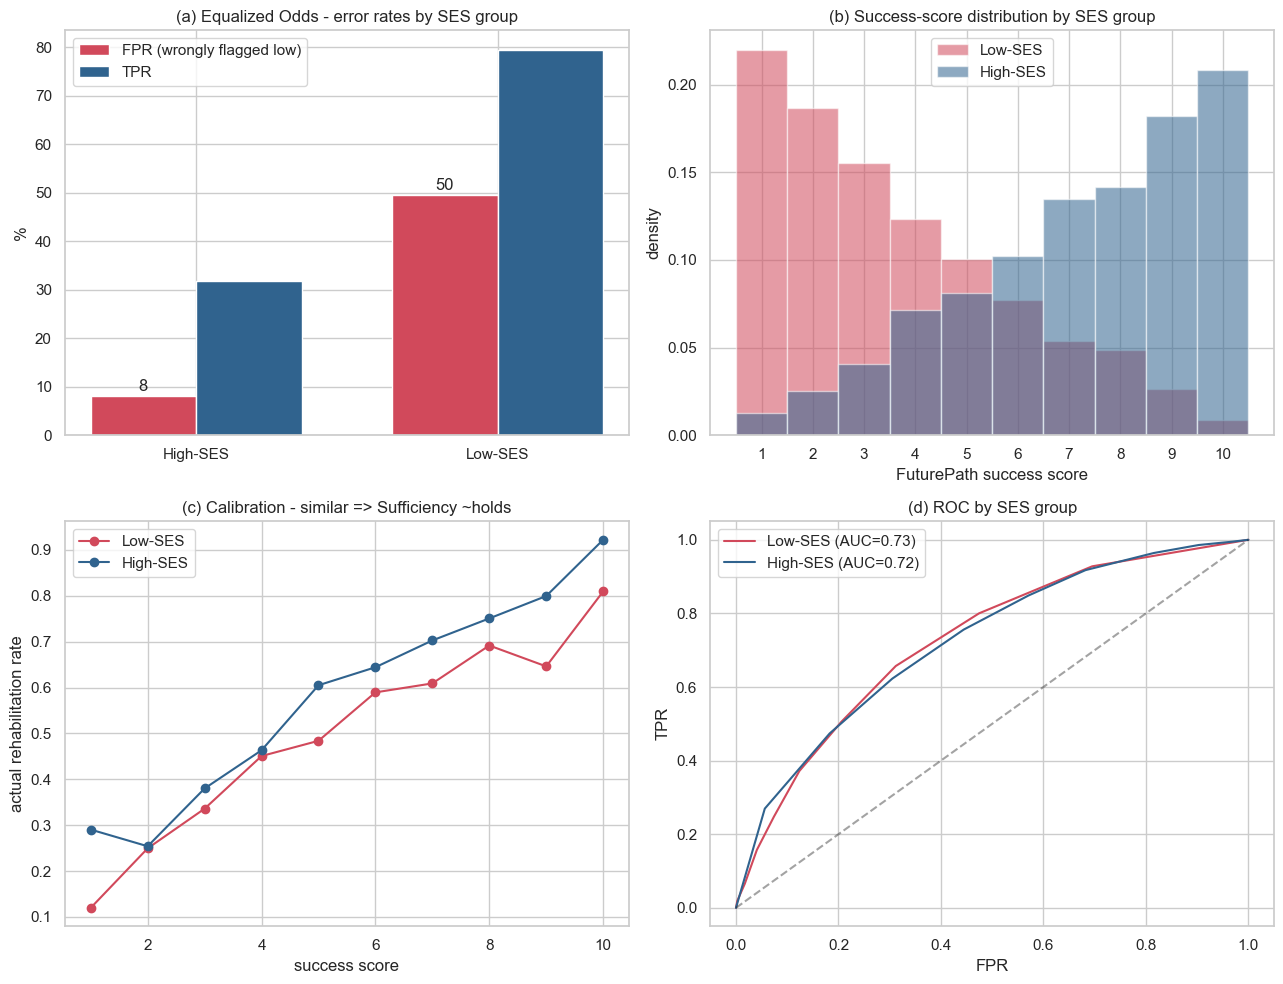

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
lo, hi = "Low-SES", "High-SES"

# (a) Equalized Odds: FPR & TPR by SES group
m = metrics.reset_index()
xpos = np.arange(len(m)); width = 0.35
ax[0,0].bar(xpos - width/2, m["False low-potential % (FPR)"], width,
            label="FPR (wrongly flagged low)", color="#d1495b")
ax[0,0].bar(xpos + width/2, m["True low-potential % (TPR)"], width,
            label="TPR", color="#30638e")
ax[0,0].set_xticks(xpos); ax[0,0].set_xticklabels(m["ses_group"])
ax[0,0].set_ylabel("%"); ax[0,0].set_title("(a) Equalized Odds - error rates by SES group")
ax[0,0].legend()
for i, v in enumerate(m["False low-potential % (FPR)"]):
    ax[0,0].text(i - width/2, v + 1, f"{v:.0f}", ha="center")

# (b) Success-score distribution by SES group
for grp, color in [(lo, "#d1495b"), (hi, "#30638e")]:
    sub = df[df.ses_group == grp]
    ax[0,1].hist(sub.success_decile, bins=np.arange(1, 12) - 0.5, density=True,
                 alpha=0.55, label=grp, color=color)
ax[0,1].set_xticks(range(1, 11))
ax[0,1].set_xlabel("FuturePath success score"); ax[0,1].set_ylabel("density")
ax[0,1].set_title("(b) Success-score distribution by SES group"); ax[0,1].legend()

# (c) Calibration: actual rehab rate vs success score, per group
for grp, color in [(lo, "#d1495b"), (hi, "#30638e")]:
    sub = df[df.ses_group == grp]
    cal = sub.groupby("success_decile")["rehab_success_true"].mean()
    ax[1,0].plot(cal.index, cal.values, "o-", label=grp, color=color)
ax[1,0].set_xlabel("success score"); ax[1,0].set_ylabel("actual rehabilitation rate")
ax[1,0].set_title("(c) Calibration - similar => Sufficiency ~holds"); ax[1,0].legend()

# (d) ROC per group (success score predicting actual rehabilitation)
for grp, color in [(lo, "#d1495b"), (hi, "#30638e")]:
    sub = df[df.ses_group == grp]
    fpr, tpr, _ = roc_curve(sub.rehab_success_true, sub.success_decile)
    auc = roc_auc_score(sub.rehab_success_true, sub.success_decile)
    ax[1,1].plot(fpr, tpr, label=f"{grp} (AUC={auc:.2f})", color=color)
ax[1,1].plot([0,1],[0,1], "k--", alpha=0.4)
ax[1,1].set_xlabel("FPR"); ax[1,1].set_ylabel("TPR")
ax[1,1].set_title("(d) ROC by SES group"); ax[1,1].legend()

plt.tight_layout(); plt.show()

---
# Phase 2 - The Field
*Does the human-in-the-loop actually protect anyone?*

The lab phase shows the **model** wrongly flags low-SES youths who would have rehabilitated
far more often. But FuturePath is *read-only* — a judge decides. Our central worry (and the
case of defendant **X**) is **automation bias**: an overloaded judge who rubber-stamps a "low
potential" score sends that youth to a **closed institution**, importing the model's
disparity straight into real placements.

We model a judge with a **reliance parameter alpha in [0, 1]**:
- with prob **alpha** the judge **defers to the tool** (divert to closed institution ⇔ flagged
  "low potential");
- with prob **1 - alpha** the judge uses **independent judgment**, modelled as
  circumstance-*blind* — diverting a fixed share of true future-failures and of true
  future-successes, identical across SES groups (so on its own it contributes **zero**
  socio-economic gap).

alpha = 0 is the careful independent judge; alpha = 1 is the pure "rubber stamp." The
**Reliance Metric** is the agreement rate between judge and machine.

In [9]:
# Independent (circumstance-blind) judge: same divert probabilities for both groups.
P_DIVERT_IF_WILL_FAIL    = 0.60   # diverts 60% of those who really would fail rehab
P_DIVERT_IF_WILL_SUCCEED = 0.20   # diverts 20% of those who would succeed -> baseline FPR 20%

def simulate(alpha, seed=1):
    rng = np.random.RandomState(seed)
    follow_machine = rng.rand(len(df)) < alpha          # automation-bias coin flip
    indep = np.where(df.actual_fail.values == 1,
                     rng.rand(len(df)) < P_DIVERT_IF_WILL_FAIL,
                     rng.rand(len(df)) < P_DIVERT_IF_WILL_SUCCEED).astype(int)
    divert = np.where(follow_machine, df.pred_fail.values, indep)
    out = df[["ses_group", "actual_fail", "pred_fail"]].copy()
    out["divert"] = divert
    return out

def field_stats(sim):
    rows = {}
    for grp, g in sim.groupby("ses_group"):
        would_succeed = g[g.actual_fail == 0]
        rows[grp] = {
            "Diversion %":          100 * g.divert.mean(),
            "Wrongful-diversion %": 100 * would_succeed.divert.mean(),  # human-decision FPR
            "Reliance (agree %)":   100 * (g.divert == g.pred_fail).mean(),
        }
    return pd.DataFrame(rows).T

lo, hi = "Low-SES", "High-SES"
alphas = np.linspace(0, 1, 11)
gap = [field_stats(simulate(a)).loc[lo, "Wrongful-diversion %"]
       - field_stats(simulate(a)).loc[hi, "Wrongful-diversion %"] for a in alphas]

print("Rubber-stamp judge (alpha = 1.0):")
print(field_stats(simulate(1.0)).round(1).to_string())
print("\nIndependent judge (alpha = 0.0):")
print(field_stats(simulate(0.0)).round(1).to_string())

Rubber-stamp judge (alpha = 1.0):
          Diversion %  Wrongful-diversion %  Reliance (agree %)
High-SES         15.0                   8.2               100.0
Low-SES          68.5                  49.5               100.0

Independent judge (alpha = 0.0):
          Diversion %  Wrongful-diversion %  Reliance (agree %)
High-SES         33.0                  21.0                66.7
Low-SES          46.3                  18.4                54.9


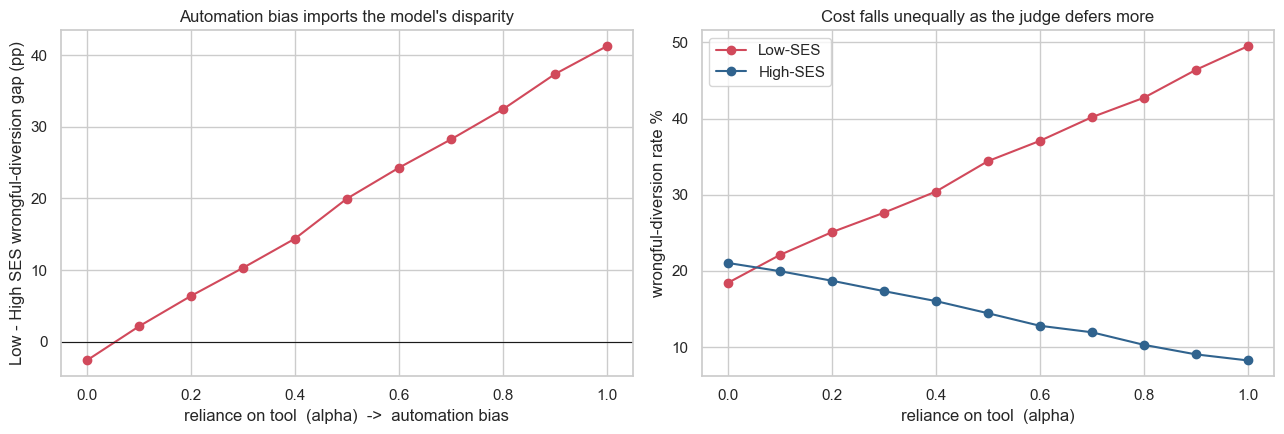

At alpha=0 the wrongful-diversion gap is ~-2.6 pp (circumstance-blind judge).
At alpha=1 it widens to ~41.3 pp - the model's disparity, fully imported.


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# How the SES gap in wrongful diversions grows with automation bias
ax[0].plot(alphas, gap, "o-", color="#d1495b")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_xlabel("reliance on tool  (alpha)  ->  automation bias")
ax[0].set_ylabel("Low - High SES wrongful-diversion gap (pp)")
ax[0].set_title("Automation bias imports the model's disparity")

# Wrongful-diversion rate by SES across alpha
wd_lo = [field_stats(simulate(a)).loc[lo, "Wrongful-diversion %"] for a in alphas]
wd_hi = [field_stats(simulate(a)).loc[hi, "Wrongful-diversion %"] for a in alphas]
ax[1].plot(alphas, wd_lo, "o-", label=lo, color="#d1495b")
ax[1].plot(alphas, wd_hi, "o-", label=hi, color="#30638e")
ax[1].set_xlabel("reliance on tool  (alpha)")
ax[1].set_ylabel("wrongful-diversion rate %")
ax[1].set_title("Cost falls unequally as the judge defers more"); ax[1].legend()

plt.tight_layout(); plt.show()

print(f"At alpha=0 the wrongful-diversion gap is ~{gap[0]:.1f} pp (circumstance-blind judge).")
print(f"At alpha=1 it widens to ~{gap[-1]:.1f} pp - the model's disparity, fully imported.")

---
## 6. Conclusions & recommendations

**Lab phase — the model penalises circumstance, not behaviour.**
- The FuturePath success score is strongly correlated with **socio-economic and family
  circumstance** (`ses_level`, `parental_stability`, school dropout) and essentially
  **uncorrelated with the youth's recent rehabilitation effort** (`has_mentor`,
  `concrete_rehab_plan`). It scores the *background*, not the *person*.
- The reconstructed scorer places the majority of its weight on **immutable / social
  features the youth did not choose** — a *feature-legitimacy* failure that no accuracy
  number can excuse.
- **Disparate Impact** of the "low-potential" flag fails the four-fifths rule (low-SES youths
  flagged far more often), and **Equalized Odds fails**: a low-SES youth who *would have
  rehabilitated* is dramatically more likely to be wrongly flagged (large FPR gap), while
  **Predictive Parity roughly holds** — the classic fairness impossibility under unequal base
  rates, so the choice of which criterion to satisfy is a *value* judgment. The gap persists
  *within* each racial group (§4b), confirming it is driven by socio-economic circumstance.

**Stale-data harm (defendant X).** The tool scored X on structural, out-of-date facts and was
**structurally blind** to his genuine turnaround — the mentor and concrete plan are not even
inputs. A read-only "decision support" tool that cannot ingest current evidence of change
**punishes people for their past circumstances** and risks a self-fulfilling prophecy: a low
score → a closed institution → worse outcomes that appear to "confirm" the prediction.

**Field phase — the human-in-the-loop is fragile.**
- With an independent judge (low alpha) the socio-economic gap in wrongful diversions nearly
  vanishes; as automation bias rises (alpha → 1) it converges on the model's full disparity.
  The "rubber stamp" judge of our case study is the worst case.
- A *read-only* tool therefore does **not** neutralise the harm — accountability depends on
  **measured** reliance behaviour, not on the disclaimer that "a judge decides."

**Recommendations (tie back to the audit objectives):**
1. **Ban morally-arbitrary features as decision drivers.** Socio-economic status, family
   structure and dropout history should not be permissible *predictors* of a child's future;
   audit and constrain their weight, don't just drop the label.
2. **Require current, changeable evidence.** Any score must ingest recent rehabilitation
   effort (school re-enrolment, mentor, concrete plan) and be re-runnable on updated facts;
   forbid placement on stale inputs.
3. **Monitor reliance in production** — log judge-vs-tool agreement on borderline (score 4-6)
   cases as a first-class fairness metric (our *Reliance Metric*).
4. **Require a written override / justification** when a judge follows a "low-potential" flag,
   converting the human from a rubber stamp into a genuine check.
5. **Report group FPR by socio-economic tier**, not just accuracy / AUC, on every release;
   gate deployment on a bounded FPR gap.

> **Auditor independence (Goodman & Trehu):** to avoid *audit-washing*, this should be run by
> an external coalition (academic Fair-ML researchers, juvenile-justice and child-welfare
> reps, civil-rights orgs) with read access to inputs, logs and outputs — not solely by the
> vendor.

> **Reproducibility & honesty.** All social-circumstance features and the FuturePath score are
> synthetic, generated deterministically by `augment_data.py` (seed 42). The disparity shown
> is a designed, reproducible illustration of the ethical question — *may a model penalise
> people for social circumstances?* — not an empirical finding about a real deployed system.